In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

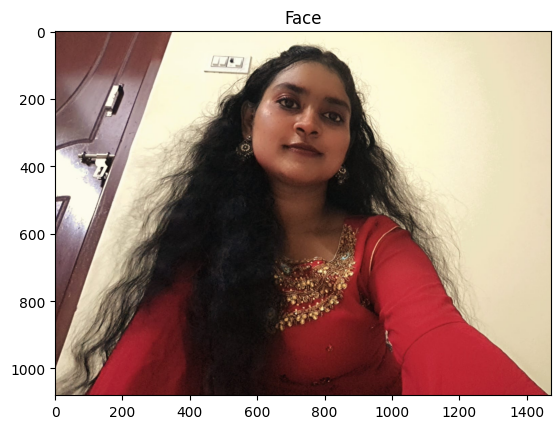

In [2]:
# Load the Face Image
faceImage = cv2.imread('mine.jpeg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(1080, 1472, 3)

In [4]:
#resized_faceImage.shape
faceImage.shape

(1080, 1472, 3)

Text(0.5, 1.0, 'glassPNG')

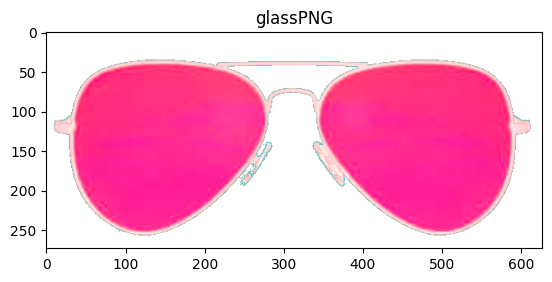

In [5]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread("gass.png",-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [27]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG, (250, 95))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(95, 250, 4)


In [28]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask = glassPNG[:,:,3]

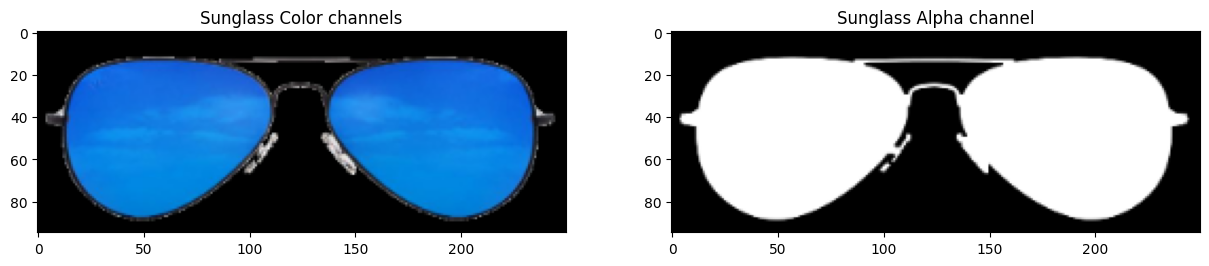

In [29]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask,cmap='gray');plt.title('Sunglass Alpha channel');

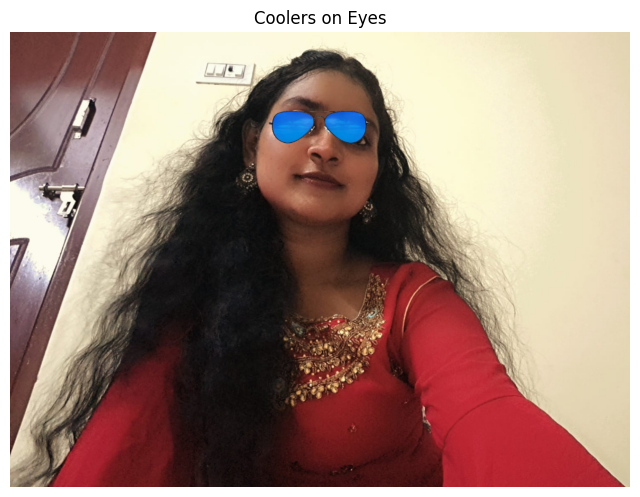

In [30]:

glassMask = cv2.merge((glassMask, glassMask, glassMask)) / 255.0

# Copy image
output = faceImage.copy()

# ==========================
# PERFECT POSITION FOR YOU
# ==========================
x1 = 610
y1 = 175

h, w = glassBGR.shape[:2]
x2 = x1 + w
y2 = y1 + h
# ==========================

# ROI
roi = output[y1:y2, x1:x2]

# Blend
bg = roi * (1 - glassMask)
fg = glassBGR * glassMask
final = np.uint8(bg + fg)

# Put back
output[y1:y2, x1:x2] = final

# Show
plt.figure(figsize=(8,8))
plt.imshow(output[:,:,::-1])
plt.title("Coolers on Eyes")
plt.axis("off")
plt.show()

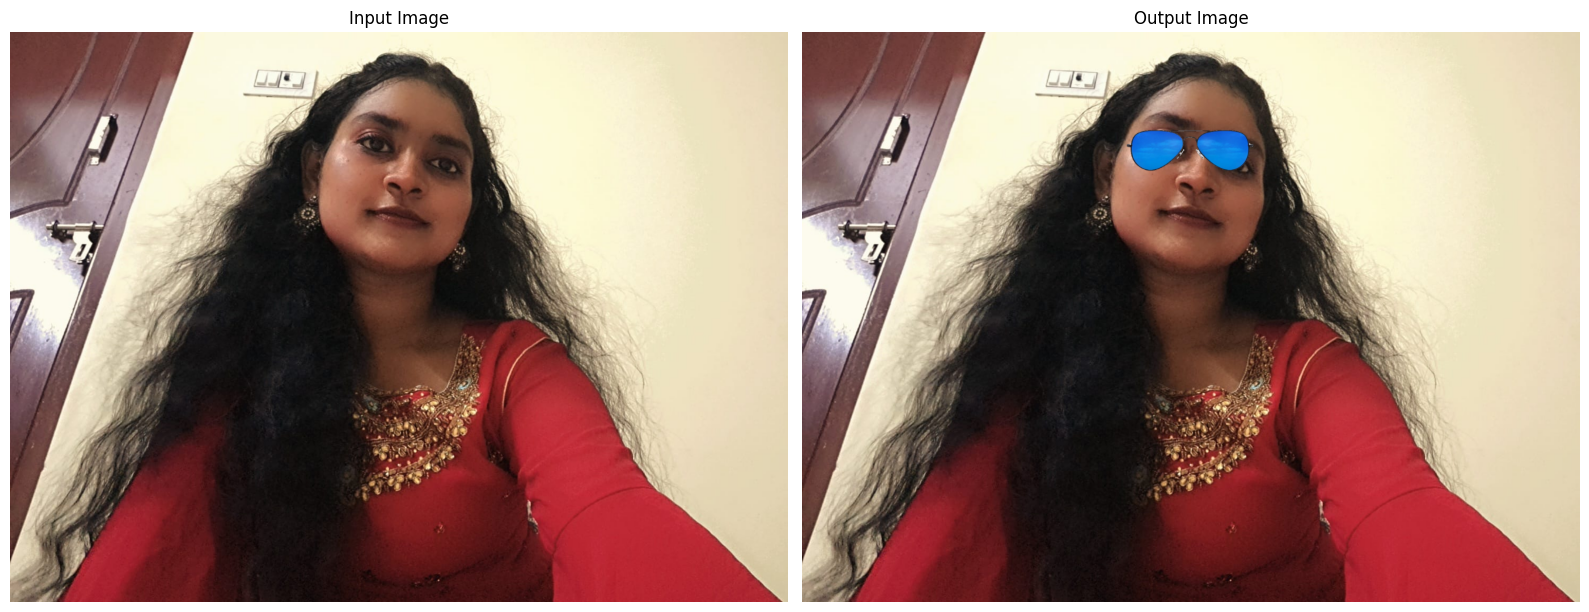

In [33]:
# Use correct variables from your code

plt.figure(figsize=(16,8))

# Input Image
plt.subplot(1,2,1)
plt.imshow(faceImage[:,:,::-1])
plt.title("Input Image")
plt.axis("off")

# Output Image
plt.subplot(1,2,2)
plt.imshow(output[:,:,::-1])   # final result variable
plt.title("Output Image")
plt.axis("off")

plt.tight_layout()
plt.show()